In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

STEP 1: SYNTHETIC DATASET GENERATED
Number of applications: 2000
Number of features: 9
Approval rate: 39.2%

STEP 2: A QUICK LOOK AT THE DATA
   annual_income  credit_score  loan_amount  employment_years  existing_debt  \
0        66704.0         646.0      20279.0               3.4         2902.0   
1        37120.0         630.0      26057.0              14.0        14928.0   
2        76510.0         713.0      20460.0               4.9        11528.0   
3        80692.0         699.0      38149.0               8.8        14895.0   
4        17077.0         575.0      30868.0              28.2        17358.0   

   num_credit_lines  has_defaulted_before  debt_to_income  loan_to_income  
0                 0                     0           0.089           0.304  
1                 9                     0           0.507           0.702  
2                 1                     0           0.191           0.267  
3                11                     0           0.256           0.473

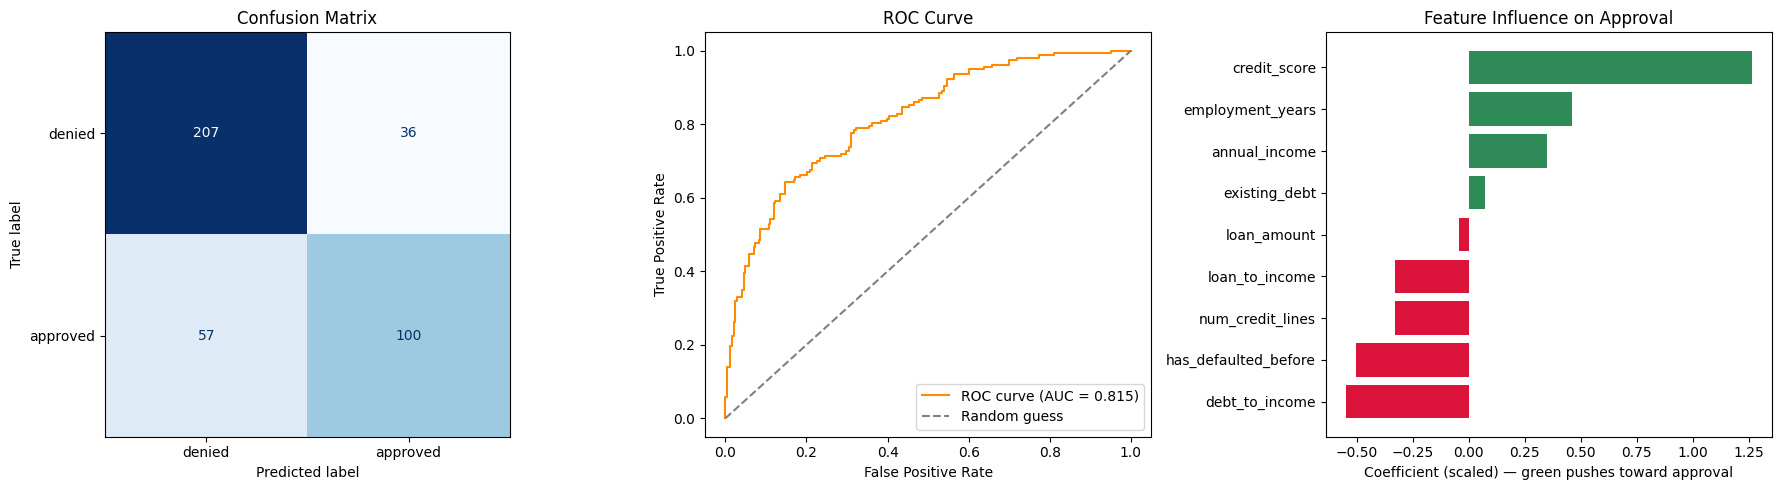

In [7]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

n_samples = 2000
annual_income = rng.normal(60000, 22000, n_samples).clip(15000, 200000)
credit_score = rng.normal(680, 75, n_samples).clip(300, 850)
loan_amount = rng.normal(18000, 9000, n_samples).clip(1000, 60000)
employment_years = rng.exponential(5, n_samples).clip(0, 40)
existing_debt = rng.normal(8000, 6000, n_samples).clip(0, 50000)
num_credit_lines = rng.integers(0, 12, n_samples)
has_defaulted_before = rng.choice([0, 1], size=n_samples, p=[0.88, 0.12])

debt_to_income = (existing_debt + loan_amount * 0.15) / annual_income
loan_to_income = loan_amount / annual_income

X_raw = pd.DataFrame({
    "annual_income": annual_income.round(0),
    "credit_score": credit_score.round(0),
    "loan_amount": loan_amount.round(0),
    "employment_years": employment_years.round(1),
    "existing_debt": existing_debt.round(0),
    "num_credit_lines": num_credit_lines,
    "has_defaulted_before": has_defaulted_before,
    "debt_to_income": debt_to_income.round(3),
    "loan_to_income": loan_to_income.round(3),
})

z = (
    0.018 * (credit_score - 650)
    - 3.0 * debt_to_income
    - 2.0 * loan_to_income
    + 0.10 * employment_years
    - 1.8 * has_defaulted_before
    + 0.00002 * (annual_income - 60000)
    - 0.05 * num_credit_lines
    + rng.normal(0, 1.0, n_samples)  # noise: real life isn't fully predictable
)
prob_approve = 1 / (1 + np.exp(-z))
approved = (rng.random(n_samples) < prob_approve).astype(int)

y = pd.Series(approved, name="approved")  # 1 = approved, 0 = denied

print("=" * 60)
print("STEP 1: SYNTHETIC DATASET GENERATED")
print("=" * 60)
print(f"Number of applications: {X_raw.shape[0]}")
print(f"Number of features: {X_raw.shape[1]}")
print(f"Approval rate: {y.mean():.1%}\n")

print("=" * 60)
print("STEP 2: A QUICK LOOK AT THE DATA")
print("=" * 60)
print(X_raw.head(), "\n")
print(X_raw.describe().T[["mean", "std", "min", "max"]], "\n")
print("Approved vs Denied counts:")
print(y.value_counts().rename({1: "approved", 0: "denied"}), "\n")


X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("=" * 60)
print("STEP 3: TRAIN / TEST SPLIT")
print("=" * 60)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("STEP 4: TRAINING THE MODEL")
print("=" * 60)
model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)
print("Model trained!\n")

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 60)
print("STEP 5: EVALUATION")
print("=" * 60)
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC:  {auc:.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["denied", "approved"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["denied", "approved"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})", color="darkorange")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

coefs = pd.Series(model.coef_[0], index=X_raw.columns).sort_values()
colors = ["crimson" if v < 0 else "seagreen" for v in coefs]
axes[2].barh(coefs.index, coefs.values, color=colors)
axes[2].set_title("Feature Influence on Approval")
axes[2].set_xlabel("Coefficient (scaled) — green pushes toward approval")

plt.tight_layout()
plt.savefig("results.png", dpi=150)
print("Saved visualizations to results.png\n")
print("=" * 60)
print("STEP 6: EXAMPLE PREDICTIONS ON NEW APPLICANTS")
print("=" * 60)



In [9]:
new_applicants = pd.DataFrame({
    "annual_income":       [95000, 32000, 55000],
    "credit_score":        [770, 580, 690],
    "loan_amount":         [15000, 20000, 12000],
    "employment_years":    [8.0, 0.5, 3.0],
    "existing_debt":       [4000, 15000, 6000],
    "num_credit_lines":    [4, 2, 5],
    "has_defaulted_before":[0, 1, 0],
})
new_applicants["debt_to_income"] = (
    new_applicants["existing_debt"] + new_applicants["loan_amount"] * 0.15
) / new_applicants["annual_income"]
new_applicants["loan_to_income"] = (
    new_applicants["loan_amount"] / new_applicants["annual_income"]
)

new_scaled = scaler.transform(new_applicants)
new_preds = model.predict(new_scaled)
new_probs = model.predict_proba(new_scaled)[:, 1]

for i in range(len(new_applicants)):
    outcome = "APPROVED" if new_preds[i] == 1 else "DENIED"
    print(
        f"Applicant {i+1}: income=${new_applicants['annual_income'][i]:,.0f}, "
        f"credit_score={new_applicants['credit_score'][i]:.0f}, "
        f"loan=${new_applicants['loan_amount'][i]:,.0f} "
        f"-> {outcome} (probability of approval: {new_probs[i]:.2f})"
    )


Applicant 1: income=$95,000, credit_score=770, loan=$15,000 -> APPROVED (probability of approval: 0.94)
Applicant 2: income=$32,000, credit_score=580, loan=$20,000 -> DENIED (probability of approval: 0.00)
Applicant 3: income=$55,000, credit_score=690, loan=$12,000 -> DENIED (probability of approval: 0.46)
